In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the dataset
df = pd.read_csv('hotel_bookings.csv')

In [ ]:
# Preview our dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# Show the shape of the dataset (rows and columns)
df.shape

(119390, 32)

In [ ]:
# Overview of the columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# check for missing values
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# Data Cleaning

In [ ]:
# Handle missing values
# 0 indicates booked directly no agency / company
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)

In [ ]:
# Drop missing values in country
df = df.dropna(subset=['country'])

In [ ]:
# Fill missing 'children' with 0
df['children'] = df['children'].fillna(0)

In [ ]:
# Fix incorrect data types
# Converts floats back to integers
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

In [ ]:
# Verify no missing values remain
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# Feature Engineering

In [ ]:
# Total nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']


In [ ]:
# Total Guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [ ]:
# is family - (True if there are children or babies, False otherwise)
df['is_family'] = (df['children'] > 0) | (df['babies'] > 0)

In [ ]:
# Season
# Mapping months to seasons
month_to_season = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
}

df['season'] = df['arrival_date_month'].map(month_to_season)

In [ ]:
# Drop rows where total_guests is 0 (an invalid booking)
invalid_bookings = df[df['total_guests'] == 0].shape[0]
invalid_bookings

161

In [ ]:
# drop invalid_bookings
df = df[df['total_guests'] > 0]

In [ ]:
# to csv file the cleaned data
df.to_csv('hotel_bookings_cleaned.csv', index=False)

# EDA

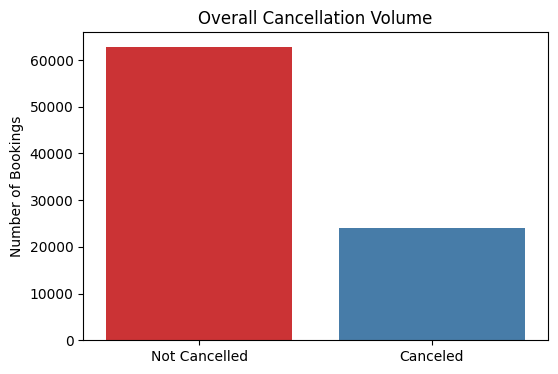

Overall Cancellation Rate: 27.6%


In [ ]:
# Overall cancelation distribution
plt.figure(figsize=(6, 4))
# mapping 0 and 1 to readable labels for the chart
df_plot = df.copy()
df_plot['is_canceled_label'] = df_plot['is_canceled'].map({0: 'Not Cancelled', 1: 'Canceled'})

sns.countplot(x='is_canceled_label', data=df_plot, hue='is_canceled_label', palette='Set1', legend=False)
plt.title('Overall Cancellation Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('')
plt.savefig('overallcancelation.png')
plt.show()

# Calculate exact percentage
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100

print(f"Overall Cancellation Rate: {cancel_pct[1]:.1f}%")

The overall cancellation rate is 27%- This is means that roughly 1 in 3 bookings ends up being cancelled. This is a massive loss pipeline for the hotels

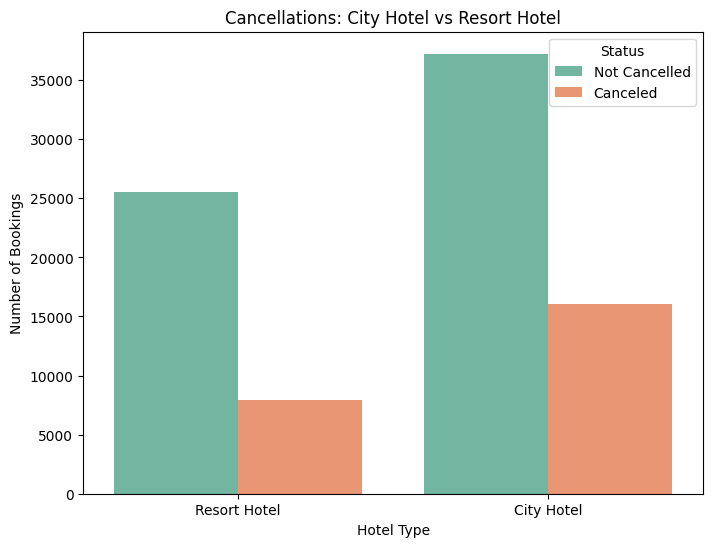

hotel         is_canceled
City Hotel    0              69.901072
              1              30.098928
Resort Hotel  0              76.289090
              1              23.710910
Name: proportion, dtype: float64


In [ ]:
# Hotel Type Comparison
# Does the type of hotel affect the likelihood of cancellation? We compare City Hotels to Resort Hotels.
plt.figure(figsize=(8,6))
sns.countplot(x='hotel', hue='is_canceled_label', data=df_plot, palette='Set2')
plt.title('Cancellations: City Hotel vs Resort Hotel')
plt.ylabel('Number of Bookings')
plt.xlabel('Hotel Type')
plt.legend(title='Status')
plt.savefig('hoteltype.png')
plt.show()

# Calculation rates per hotel type
print(df.groupby('hotel')['is_canceled'].value_counts(normalize=True) * 100)

City Hotels see significantly higher booking volumes but they also suffer from a much higher cancellation rate compared to Resort Hotels.

City trips are often short, impulsive, or tied to business meetings that get moved. Resort trips are usually planned vacations(often involving flights) maing guests much less likely to abandon their plans.

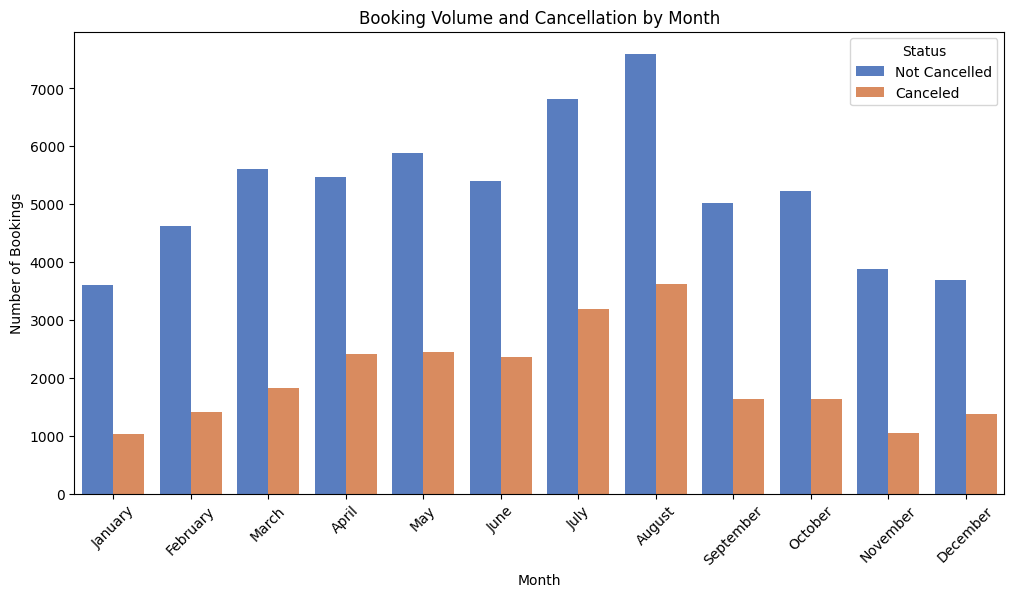

In [ ]:
# Monthly Trends(Seasonality)
plt.figure(figsize=(12,6))

# define chronological order for months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']
sns.countplot(x='arrival_date_month', hue='is_canceled_label',
              data=df_plot, order=month_order, palette='muted')
plt.title('Booking Volume and Cancellation by Month')
plt.ylabel('Number of Bookings')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.savefig('monthlytrends.png')
plt.show()


July and August are our peak months, aligning with the European summer holiday season.
Because demand naturally outstrips supply during these months the hotel has leverage.

Recommendation:

The hotel should implement stricter, non-refundable booking rates during the summer because they can easily finfd replacement guests.

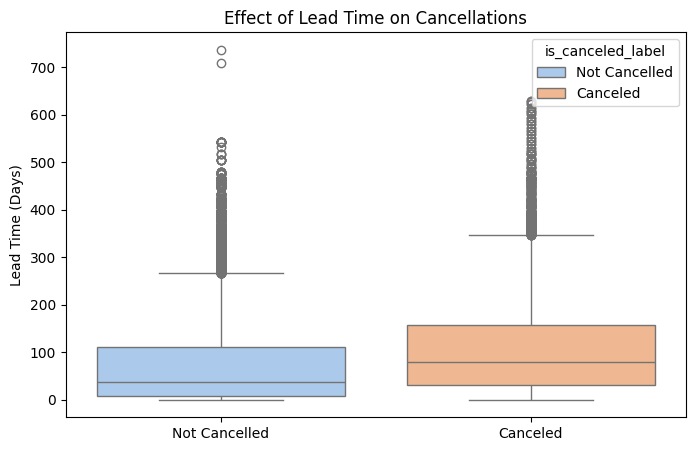

In [ ]:
# Lead Time Analysis
# Lead time is the number of days between when the a guest books a room and when they actually arrive
# Does booking in advance make a guest more likely to cancel
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled_label', y='lead_time', data=df_plot, hue='is_canceled_label', palette='pastel', legend=True)
plt.title('Effect of Lead Time on Cancellations')
plt.ylabel('Lead Time (Days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()

The boxplot clearly shows that the lead time for canceled booking is much higher. - Basically: the earlier someone books, the more time they have to change their mind, find a better deal or experience a schedule change.

Recommendation:

Introduce a progressive deposit system where bookings made more than 90 days in advance require a 20% non refundable deposit

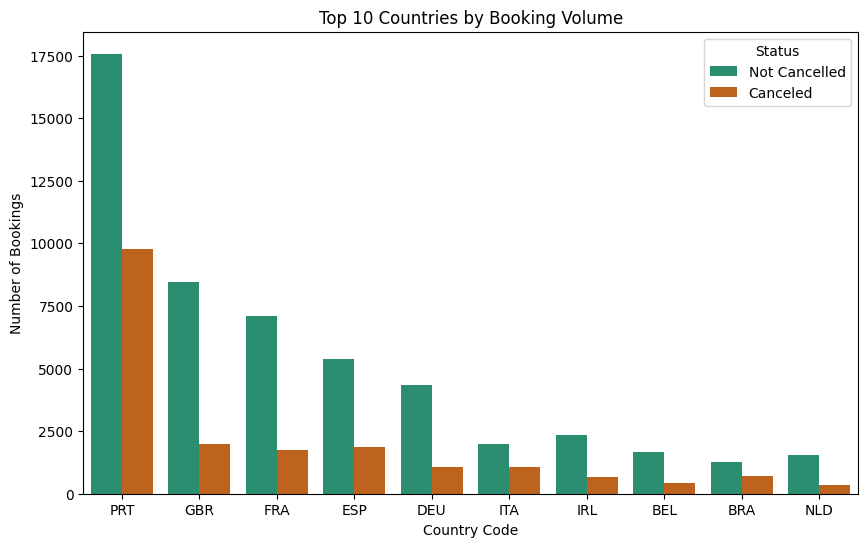

In [ ]:
# Country Distribution
# Top 10 Countries
plt.figure(figsize=(10,6))
# Get top 10 countries by volume
top_10_countries = df['country'].value_counts().head(10).index

sns.countplot(x='country', hue='is_canceled_label', data = df_plot[df_plot['country'].isin(top_10_countries)]
            ,order = top_10_countries, palette='Dark2')
plt.title('Top 10 Countries by Booking Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('Country Code')
plt.legend(title='Status')
plt.savefig('countrydistribution.png')
plt.show()


PRT(Portugal) generate the highest volume of bookings, but it also has a staggering cancelation rate of 50%. Because the hotels in this dataset are located in Portugal, these are local residents. Locals often book multiple hotels as "backups" for weekend getaways because they don't have to commit to flights. International guests(GBR, FRA, DEU) rarely cancel because their travel plans are locked in by airline tickets.

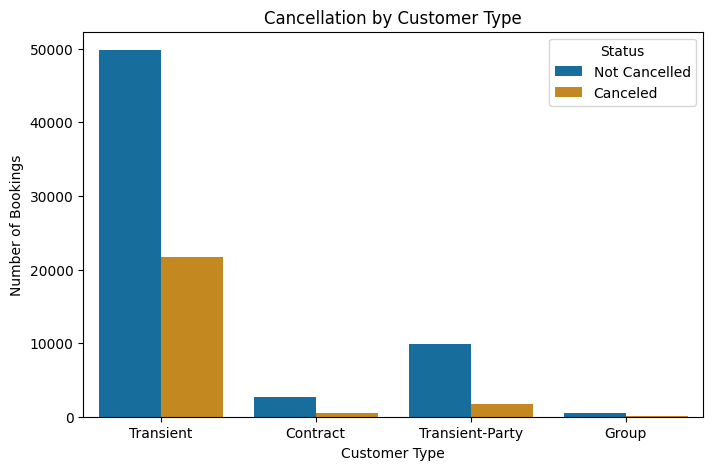

In [ ]:
# Customer Type Analysis
# Are solo/transient travellers more volatile than large groups or corporate contracts?
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='is_canceled_label', data=df_plot, palette='colorblind')
plt.title('Cancellation by Customer Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Customer Type')
plt.legend(title='Status')
plt.savefig('customertype.png')
plt.show()

Transient Travellers (Independent/Solo traveller not part of a group) account for the vast majority of bookings and cancellations. Conversely, 'Groups' and  'Contract' bookings are much more stable.

Recommendation:
The sales team should prioritize securing more B2B contracts and group events to build a stable, guaranted revenue base that protects against the volatility of Individual Transients.